# Method Analysis

* VNeo method parsing adapted from from https://github.com/nickdelgrosso/XCaliburMethodReader/tree/master

## Imports

In [1]:
# import olefile
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns
import os
import sys
import anndata as ad

%matplotlib inline

In [2]:
%load_ext autoreload
%autoreload 2

# Add parent directory to path to import modules from code/
sys.path.insert(0, os.path.abspath('..'))

from vneo_method import VNeoMethod
from lc_method_collection import VNeoMethodCollection
from ms_method import MicroTOFMethod
from ms_method_collection import MSMethodCollection
from anndiannloader import DiannLoader as dl
from diann_collection import DiannCollection
from filters import filter_mask
from method_mapper import map_lcms_methods
import precursor_window_analysis as pwa

# from plotting import Plotter

## Base

In [3]:
source = 'base'

In [4]:
if source == 'base':
    base = '/hpc/projects/mass_spec/eileenwang/'

## Load LC Methods

#### LC Collection Object

In [5]:
lccollection = VNeoMethodCollection()

In [6]:
lccollection.add_methods_from_folder(f'{base}MethodOpt/LCMSmethodAnalysis/SampleData/methods/LC')

/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/code/vneo_method.py:127: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  gradient_df[col] = pd.to_numeric(gradient_df[col], errors='ignore')
/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/code/vneo_method.py:130: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  equil_df[col] = pd.to_numeric(equil_df[col], errors='ignore')


In [45]:
lccollection.methods['17p5m150nlv13'].runtime

17.5

<Axes: title={'center': 'Gradient Comparison: 17p5m150nlv13, 20p5m150nlv6'}, xlabel='time [min]', ylabel='Nominal [µl/min]'>

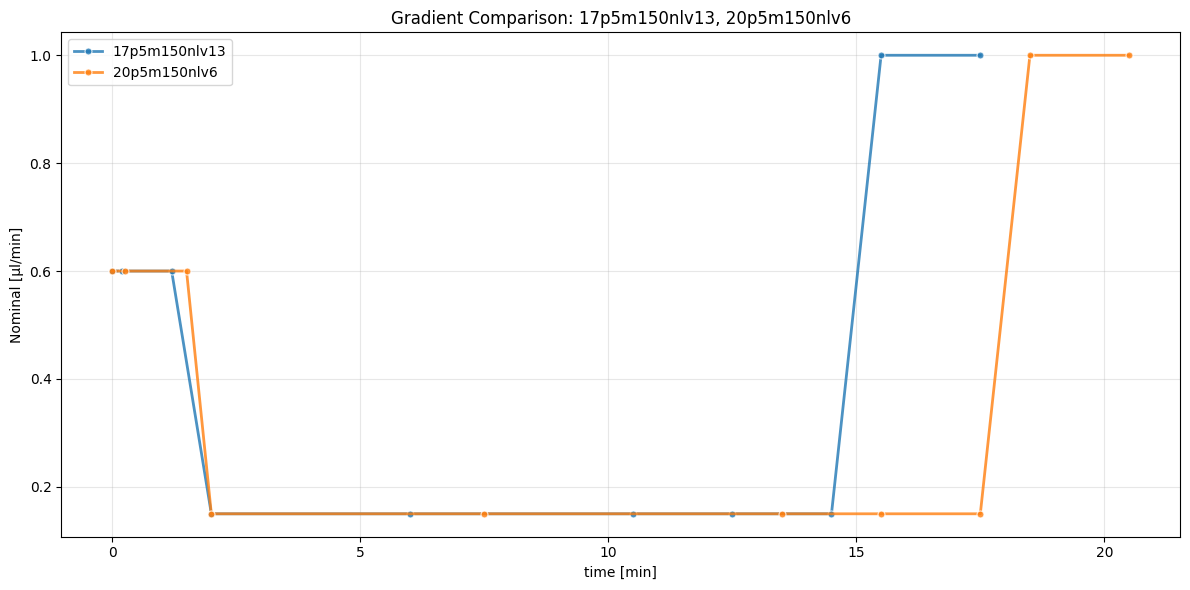

In [17]:
lccollection.plot_gradients(['17p5m150nlv13', '20p5m150nlv6'],
                        x_col = 'time [min]',
                        y_cols = ['Neo.PumpModule.Pump.Flow.Nominal [µl/min]'], 
                        twin_axes=True , 
                        markers=True
)

<Axes: title={'center': 'Gradient Comparison: 17p5m150nlv13, 23p75m150nlv16, 24m150nlThermo, 20m150nlv15, 20m150nlML30mA15v2, 36m150nlLong40, 18p6m200nlv28drop, 17p75m150nlv12, 23m150nlv21Zebra, 10m150nlRainmanA15-75, 11p5m150nlv9, 20m150nlML30mA15phospho4, 25m200nlv5, 20m150nlML23p5mA15v1, 20p5m150nlv14, 23p65m150nlv18Zebra, 25m150nlv5, 27m150nlv3, 19m200nlv26, 25m200nlv24, 19m200nlv25, 25m200nlv23, 19m200nlv27PC2drop, 16m150nlv8, 18p5m200nlv29, 20p5m150nlv6, 17p5m150nlv10, 18p6m200nlv30, 25m150nlv4, 25p15m150nlv22Zebra, 36m150nlSlow40, 23p65m150nlv19Zebra, 20p5m150nlv7, 25p15m150nlv20Zebra, 17p7m150nlv11, 23p75mHighACNWash150nlv17'}, xlabel='time [min]', ylabel='Value [%]'>

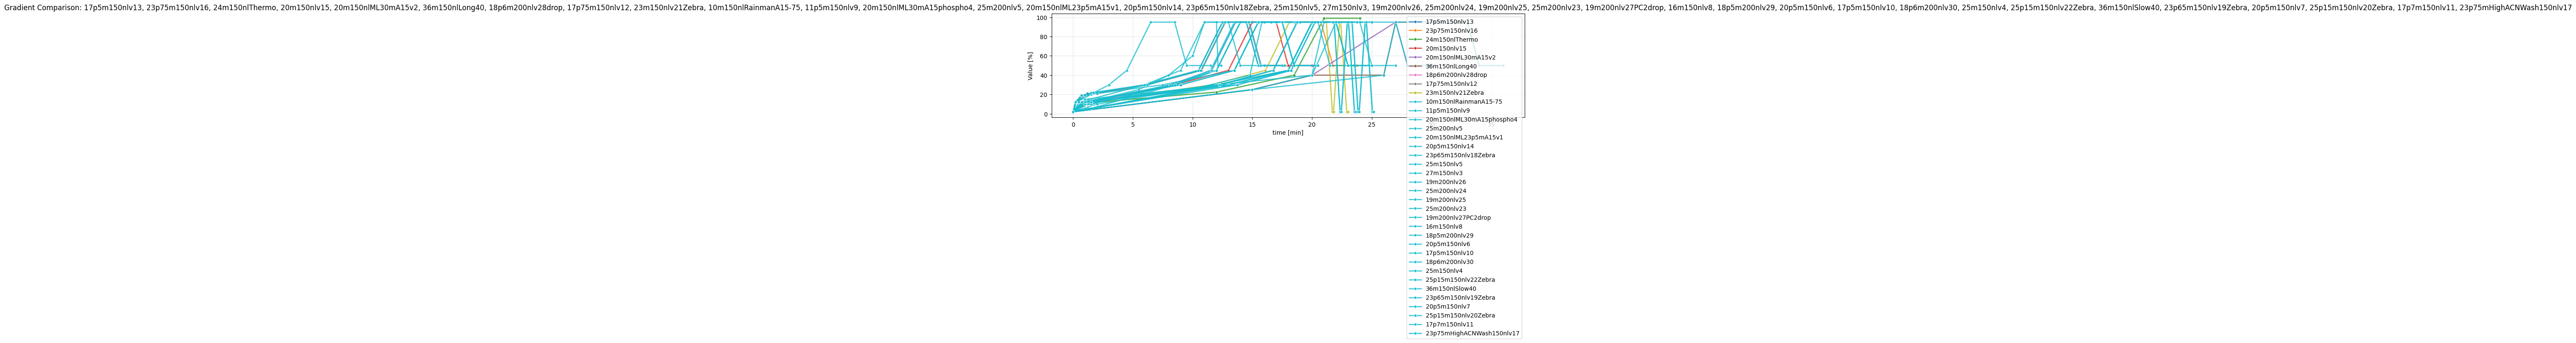

In [7]:
lccollection.plot_gradients(
                        x_col = 'time [min]',
                        y_cols = ['Neo.PumpModule.Pump.%B.Value [%]'], 
                        twin_axes=True , 
                        markers=True
)

## MS Methods

### Load MS Methods

In [7]:
# Intialize MS method collector object
mscollection = MSMethodCollection()

In [8]:
# # Method 1: Add single method with explicit name
# collection.add_method("/Users/eileen.wang/Desktop/diann/SampleData/methods/MS/DIA003.proteoscape.m")

# Method 2: Add from zip file (extracts and adds all methods inside)
mscollection.add_methods_from_folder(f"{base}/MethodOpt/LCMSmethodAnalysis/SampleData/methods/MS/msmethods.zip")
# collection.add_methods_from_paths(["/Users/eileen.wang/Desktop/diann/SampleData/methods/MS/DIA003.proteoscape.m"], overwrite = 'ignore')
msmethod_names = '\n'.join(mscollection.methods.keys())
# print(f"Loaded {len(mscollection)} methods: {msmethod_names}")


### MS Meth Summary

### Find Differences between methods

In [28]:
method = mscollection['DIA011RT70expandedrange']
value = method['Collision_GasSupply_Set']  # Direct access!
# cap_voltage = method['default_Source_CapillarySetValue']  # Positive only
windows = method['dia_windows']  # Direct access!


In [29]:
df = mscollection.to_dataframe(
    method_names=['DIA007', 'DIA016'],  # Optional: subset methods
    # param_names=['Collision_GasSupply_Set', 'dia_window_count'],  # Optional: subset params
    exclude_dia_windows=True  # Exclude DataFrame objects by default
)

In [30]:
df = mscollection.to_dataframe()

In [37]:
df.columns[50:100]

Index(['CollisionSweep_CollisionEnergy_Factor_Set',
       'CollisionSweep_CollisionRF_Factor_Set', 'CollisionSweep_Mode_Set',
       'CollisionSweep_Switch_Set', 'CollisionSweep_Time_Set',
       'CollisionSweep_TransferTime_Factor_Set', 'Collision_RF_Set',
       'Digitizer_SpectraRate', 'Digitizer_SpectraRateMode',
       'Digitizer_SpectraSampleTime', 'Digitizer_Summation',
       'IMSICC_ICC2_MaxTicTargetPercent', 'IMSICC_ICC2_MinAccuTime',
       'IMSICC_ICC2_ReferenceTicCapacity', 'IMSICC_ICC2_SmoothingFactor',
       'IMSICC_Mode', 'IMSICC_Target', 'IMS_ATS_Active', 'IMS_ATS_Profile',
       'IMS_MobilogramTraceColor', 'IMS_MobilogramTraceDefinition',
       'IMS_MobilogramTraceShow', 'IMS_PolygonFilter_ActiveMode',
       'IMS_PolygonFilter_Color', 'IMS_PolygonFilter_Id',
       'IMS_PolygonFilter_Mass', 'IMS_PolygonFilter_Mobility',
       'IMS_PolygonFilter_Type', 'IMS_Processing_Mz_ThresholdSignalToNoiseAbs',
       'IMS_Processing_SwitchCalcIntegratedIntensity', 'IMS_RampO

In [25]:
# finding differences between 2+ methods
diff = mscollection.find_differences(['DIA011RT60','DIA018'])
diff

,Parameter,Type,Description,DIA011RT60,DIA018
0,TOF_DetectorTofSetValue,instrument_param,,2265.0,2252.0
1,Vacuum_LastCapillaryCleaningDate,instrument_param,,2025-11-24T12:05:17-08:00,2025-08-18T09:57:05-07:00
2,default_IMS_Calibration_LastCalibrationResultM...,polarity_param,positive polarity,"[0.991490526184405, 1.198496661468722, 1.39345...","[0.9915975556776143, 1.1981088474531307, 1.393..."
3,default_IMS_Calibration_LastCalibrationMassInt...,polarity_param,positive polarity,"[1445930.0230822468, 1471710.2676116882, 75735...","[787028.996186168, 1230470.924191452, 177976.4..."
4,default_IMS_Calibration_LastCalibrationCurrent...,polarity_param,positive polarity,"[0.9918083576587342, 1.1996513792348398, 1.395...","[0.9911200443893721, 1.1903158790947799, 1.376..."
5,default_IMS_CalibrationCoefficients,polarity_param,positive polarity,"[0.03084927968991898, 160.35509090775577, 15.9...","[0.001523152265349233, 165.08327143248422, 16...."
6,default_IMS_Calibration_StdDev,polarity_param,positive polarity,0.000138,0.000599
7,default_IMS_CalibrationRampStart,polarity_param,positive polarity,243.402636,239.900581
8,default_IMS_Calibration_Funnel1In_Pressure,polarity_param,positive polarity,2.387,2.403
9,default_IMS_CalibrationRampEnd,polarity_param,positive polarity,139.972162,140.502687


#### Plotting differences

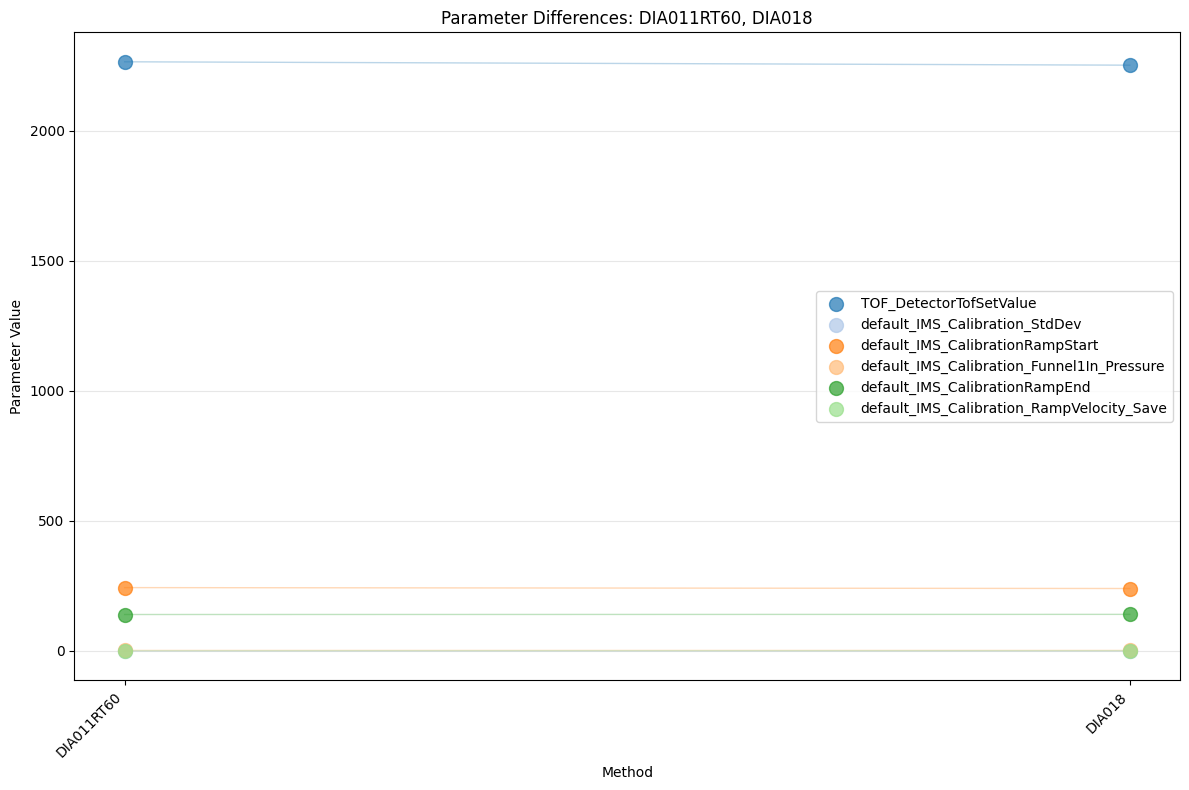

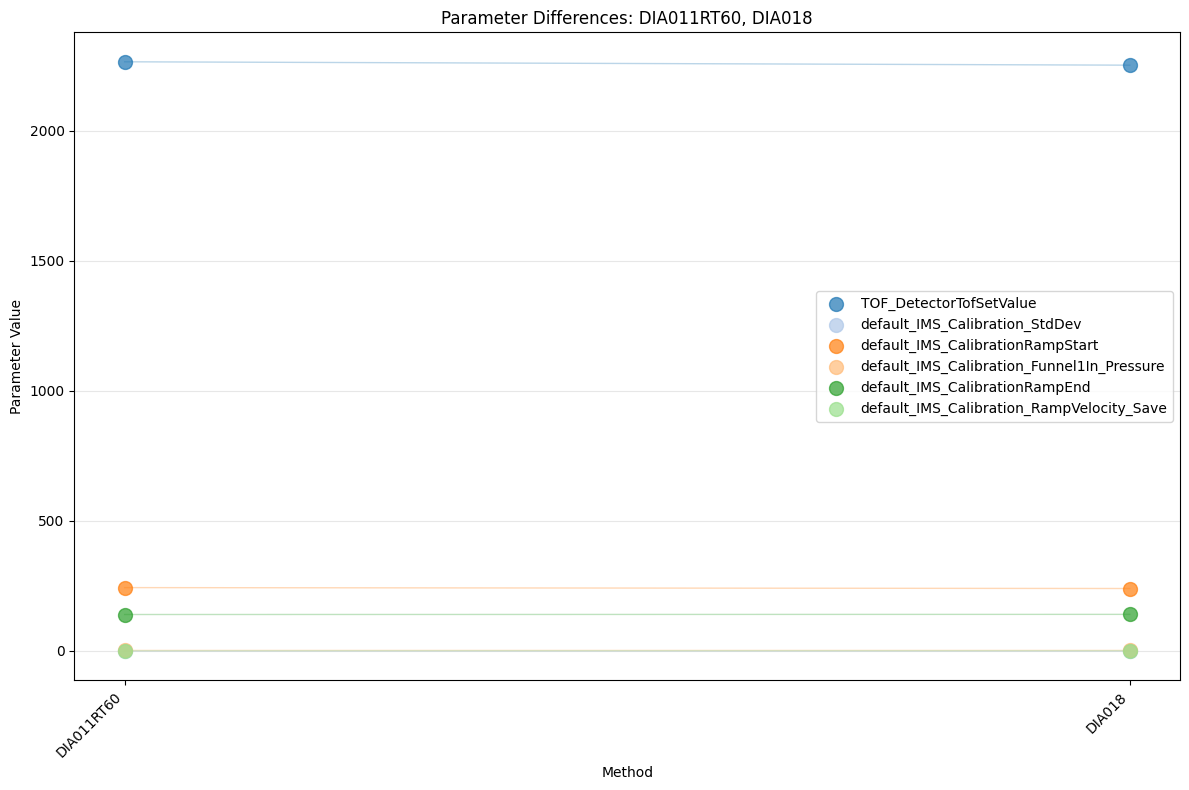

In [27]:
mscollection.plot_differences(method_names = ['DIA011RT60',
                                              'DIA018'],
                                              
)

### Plot DIA Windows

In [68]:
methods = ['DIA60msW102', 'DIA75msW82', 'DIA50msW122', 'DIA011RT75expandedrange', 'DIA011RT75expandedrangeW83',
           'DIA60msW102_C2', 'DIA75msW82_C2', 'DIA50msW122_C2']

<Axes: title={'center': 'DIA Windows Overlay: DIA75msW82, DIA50msW122, DIA011RT75expandedrangeW83'}, xlabel='m/z', ylabel='1/K0 (Ion Mobility)'>

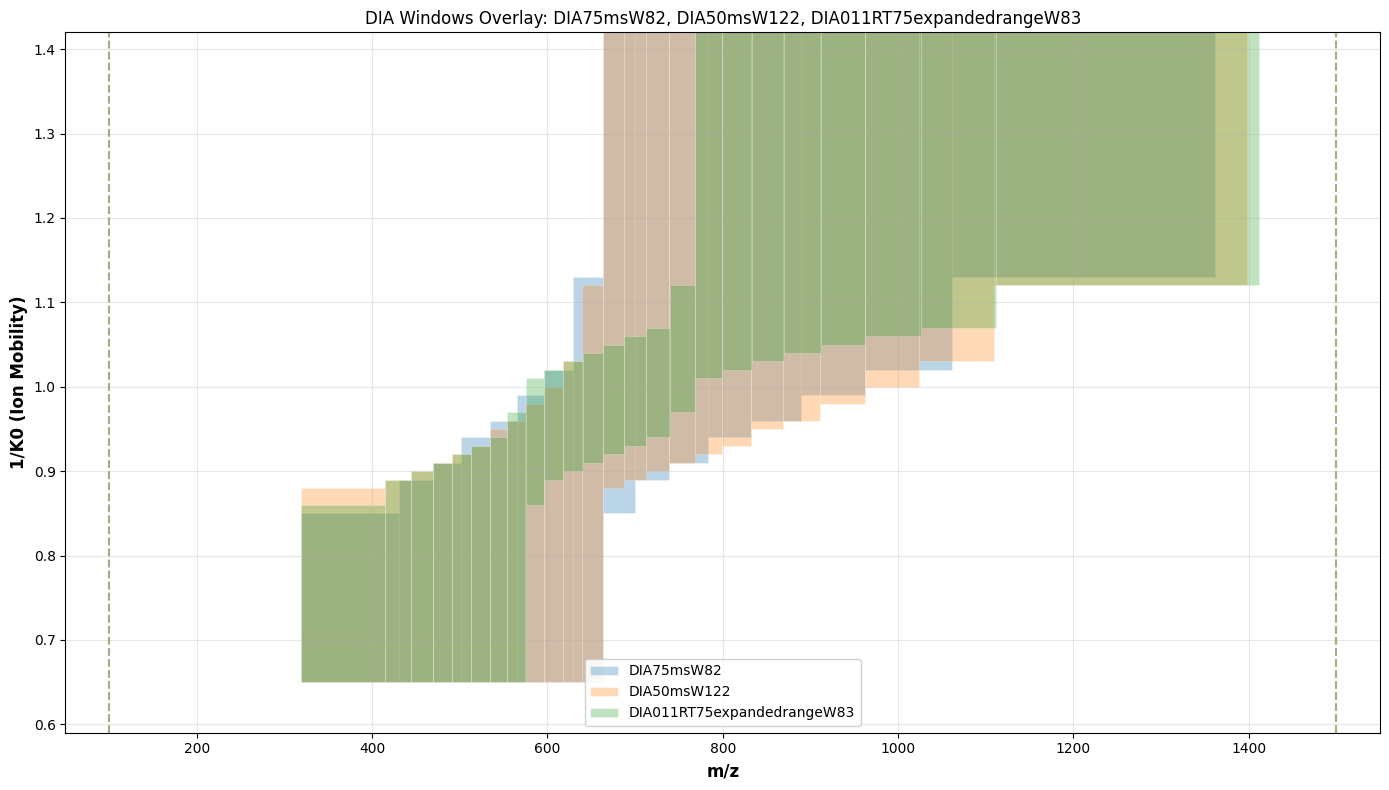

In [67]:
mscollection.plot_windows(['DIA75msW82', 'DIA50msW122', 'DIA011RT75expandedrangeW83'], color_by_method=True,
                    alpha=0.3,
                    # edge_color='white',
                    # figsize=(14, 8),
                    show_labels=False)

## Loading Searches

### BPS

In [22]:
# bpscollection = DiannCollection(log_file = f'{base}/MethodOpt/outputs/bpscollection.log')

In [23]:
# bpscollection.add_searches([f'{base}/MethodOpt/LCMSmethodAnalysis/SampleData/BPS/New Folder/{i}' for i in os.listdir(f'{base}/MethodOpt/LCMSmethodAnalysis/SampleData/BPS/New Folder')[:2]],
#                             search_type='bps',
#                             levels=['precursor'])

In [9]:
bpscollection = DiannCollection.from_file(f'{base}/MethodOpt/outputs/bpscollection.pkl')

Loaded collection from /hpc/projects/mass_spec/eileenwang/MethodOpt/outputs/bpscollection.pkl


In [10]:
# map_lcms_methods(bpscollection, ['/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/SampleData/Sequences/2026_01_lcmsmethodmapping.csv',
#                                  '/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/SampleData/Sequences/2026_02.csv'])

In [11]:
# bpscollection.save(f'{base}/MethodOpt/outputs/bpscollection.pkl')

Saved collection to /hpc/projects/mass_spec/eileenwang/MethodOpt/outputs/bpscollection.pkl


In [ ]:
import zipfile
import pandas as pd
import os
from pathlib import Path

# Find all zip files in the BPS directory
zip_files = []
bps_path = f'{base}/MethodOpt/LCMSmethodAnalysis/SampleData/BPS'

# Recursively find all zip files
for root, dirs, files in os.walk(bps_path):
    for file in files:
        if file.endswith('.zip'):
            zip_files.append(os.path.join(root, file))

# Read metadata.csv from each zip file and combine into a single dataframe
metadata_dfs = []

for zip_path in zip_files:
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            # Try to find metadata.csv in the zip file
            csv_files = [f for f in zip_ref.namelist() if f.endswith('metadata.csv')]
            
            if csv_files:
                # Read the first metadata.csv file found
                metadata_file = csv_files[0]
                with zip_ref.open(metadata_file) as f:
                    df = pd.read_csv(f)
                    # Add the zip file path as a column
                    df['zip_path'] = zip_path
                    metadata_dfs.append(df)

                
    except Exception as e:
        print(f"  ✗ Error processing {zip_path}: {e}")

# Combine all metadata dataframes
if metadata_dfs:
    combined_metadata = pd.concat(metadata_dfs, ignore_index=True)

else:
    print("No metadata files found!")
    combined_metadata = None

### Fragpipe

In [81]:
fpcollection = DiannCollection(log_file = f'{base}/MethodOpt/outputs/fpcollection.log')

In [82]:
fpcollection.add_searches(f"/hpc/projects/mass_spec/projects/SHEI004/search_result/fragpipe/EW/SHEI004_DIAonly/workingDir", 
                               search_type='fragpipe', 
                               levels=['precursor'])

In [14]:
# fpcollection.save(f'{base}/MethodOpt/outputs/fpcollection.pkl')

Saved collection to /hpc/projects/mass_spec/eileenwang/MethodOpt/outputs/fpcollection.pkl


In [10]:
fpcollection = DiannCollection.from_file(f'{base}/MethodOpt/outputs/fpcollection.pkl')

Loaded collection from /hpc/projects/mass_spec/eileenwang/MethodOpt/outputs/fpcollection.pkl


In [ ]:
# Summary
# # summary = collection.summary_df()
# # print(summary)

### Combine Sample and Method

In [ ]:
# map_lcms_methods(fpcollection, '/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/SampleData/Sequences/2026_01_lcmsmethodmapping.csv')

/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/SampleData/Sequences/2026_01_lcmsmethodmapping.csv
/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/SampleData/Sequences/2026_02.csv


### Plotting/Analysis

#### Checkign distribution of Values

In [29]:
def check_dist(ad, layer, samples=None, figsize=(10,6)):
    fig, ax = plt.subplots(figsize=figsize)
    df = ad.to_df(layer)
    if samples:
        df = df.loc[:, samples]

    df = df.melt(value_name=layer)

    for s in df.columns:
        sns.violinplot(data = df, x = 'File.Name', y = layer, ax=ax)
    
    plt.xticks(rotation=90)

## Compute CV

In [12]:
test = bpscollection['precursor'][:, bpscollection['precursor'].var['ms meth'].isin(['DIA003', 'DIA011RT75expandedrangeW83'])]

In [13]:
test2 = test[:, test.var['hystar_index'].astype(int) > 14701]

In [14]:
test2.var['File.Name'] = test2.var.index

/tmp/ipykernel_3371188/3159618787.py:1: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  test2.var['File.Name'] = test2.var.index


In [19]:
test2.var['input'] = test2.var['File.Name'].str.extract(r'HeLa_(\d+[np]g)_')

In [20]:
test2.layers['RTDiff'] = test2.layers['RT.Stop'] - test2.layers['RT.Start']

In [34]:
sample = 'HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_19mv45_DIA75msW83_TT0000314_B-B2_1_14717'

In [201]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Extract data arrays
mz_data = test2[:, sample].layers['Precursor.Calibrated.Mz'].astype(float).flatten()
k0_data = test2[:, sample].layers['Exp.1/K0'].astype(float).flatten()
quantity_data = test2[:, sample].layers['Precursor.Quantity'].astype(float).flatten()

# Calculate log2 intensities and handle invalid values
log2_quantity = np.log2(np.where(quantity_data > 0, quantity_data, np.nan))

# Create intensity bins/ranges for toggles
valid_mask = np.isfinite(log2_quantity) & np.isfinite(mz_data) & np.isfinite(k0_data)
valid_log2 = log2_quantity[valid_mask]

if len(valid_log2) > 0:
    # Define intensity ranges using percentiles
    percentiles = [0, 20, 40, 60, 80, 100]
    bin_edges = np.percentile(valid_log2, percentiles)
    bin_labels = [f'Very Low ({bin_edges[0]:.1f} - {bin_edges[1]:.1f})',
                  f'Low ({bin_edges[1]:.1f} - {bin_edges[2]:.1f})', 
                  f'Medium ({bin_edges[2]:.1f} - {bin_edges[3]:.1f})',
                  f'High ({bin_edges[3]:.1f} - {bin_edges[4]:.1f})',
                  f'Very High ({bin_edges[4]:.1f} - {bin_edges[5]:.1f})']
    
    # Assign bins to all data points
    intensity_bins = np.full(len(log2_quantity), 'No Signal')
    for i in range(len(bin_edges)-1):
        if i == 0:
            mask = (log2_quantity >= bin_edges[i]) & (log2_quantity <= bin_edges[i+1])
        else:
            mask = (log2_quantity > bin_edges[i]) & (log2_quantity <= bin_edges[i+1])
        intensity_bins[mask] = bin_labels[i]
    
    # Create DataFrame for Plotly
    df_plot = pd.DataFrame({
        'mz': mz_data,
        'k0': k0_data,
        'log2_quantity': log2_quantity,
        'intensity_bin': intensity_bins
    })
    
    # Remove invalid data
    df_plot = df_plot[valid_mask]
    
    # Create interactive scatter plot with toggles
    fig = px.scatter(df_plot, 
                     x='mz', 
                     y='k0',
                     color='log2_quantity',
                     color_continuous_scale='icefire',
                     opacity=0.6,
                     hover_data=['intensity_bin'],
                     labels={
                         'mz': 'Precursor m/z',
                         'k0': 'Experimental 1/K0', 
                         'log2_quantity': 'Log2(Intensity)',
                         'intensity_bin': 'Intensity Range'
                     },
                     title=f'Precursor Distribution - {sample}')
    
    # Set y-axis limits to match original plot
    fig.update_yaxes(range=[0.65, 1.45])
    
    # Add dropdown menu for intensity range selection
    buttons = []
    
    # Add "All" button
    buttons.append(dict(
        label="All Ranges",
        method="restyle",
        args=[{"visible": [True] * len(df_plot)}]
    ))
    
    # Add buttons for each intensity range
    for bin_label in bin_labels:
        visible_mask = df_plot['intensity_bin'] == bin_label
        buttons.append(dict(
            label=bin_label,
            method="restyle", 
            args=[{"visible": visible_mask.tolist()}]
        ))
    
    # Update layout with dropdown
    fig.update_layout(
        updatemenus=[
            dict(
                buttons=buttons,
                direction="down",
                showactive=True,
                x=1.02,
                y=1.0,
                xanchor="left",
                yanchor="top"
            )
        ],
        width=900,
        height=600,
        margin=dict(r=200)  # Make room for dropdown
    )
        
    print(f"Created interactive plot with {len(df_plot)} precursors")
    print(f"Intensity ranges (Log2):")
    for label in bin_labels:
        count = (df_plot['intensity_bin'] == label).sum()
        print(f"  {label}: {count} precursors")
else:
    print("No valid data found for plotting")

Created interactive plot with 84744 precursors
Intensity ranges (Log2):
  Very Low (9.1 - 14.0): 0 precursors
  Low (14.0 - 14.9): 0 precursors
  Medium (14.9 - 15.7): 0 precursors
  High (15.7 - 16.8): 0 precursors
  Very High (16.8 - 24.1): 0 precursors


In [202]:
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
# Alternative version with checkbox toggles for multiple selections
if len(valid_log2) > 0:
    # Create separate traces for each intensity range
    fig_multi = go.Figure()
    
    colors = px.colors.qualitative.Set2
    
    for i, bin_label in enumerate(bin_labels):
        bin_data = df_plot[df_plot['intensity_bin'] == bin_label]
        
        fig_multi.add_trace(
            go.Scatter(
                x=bin_data['mz'],
                y=bin_data['k0'],
                mode='markers',
                name=bin_label,
                marker=dict(
                    color=colors[i % len(colors)],
                    size=4,
                    opacity=0.7
                ),
                customdata=bin_data[['log2_quantity']],
                hovertemplate='<b>%{fullData.name}</b><br>' +
                             'm/z: %{x:.2f}<br>' +
                             '1/K0: %{y:.3f}<br>' +
                             'Log2(Intensity): %{customdata[0]:.2f}<br>' +
                             '<extra></extra>',
                visible=True
            )
        )
    
    # Update layout with checkboxes
    fig_multi.update_layout(
        title=f'Interactive Precursor Distribution - {sample}<br><sub>Use legend to toggle intensity ranges on/off</sub>',
        xaxis_title='Precursor m/z',
        yaxis_title='Experimental 1/K0',
        yaxis=dict(range=[0.65, 1.45]),
        width=900,
        height=600,
        legend=dict(
            orientation="v",
            x=1.02,
            y=1.0,
            bgcolor="rgba(255,255,255,0.8)"
        ),
        margin=dict(r=200)
    )
    
    fig_multi.show()
    
    print(f"\nAlternative interactive plot with checkbox toggles")
    print("Click on legend items to toggle visibility of intensity ranges")
else:
    print("No valid data found for plotting")

View of AnnData object with n_obs × n_vars = 0 × 1
    obs: 'Modified.Sequence', 'Stripped.Sequence', 'Precursor.Charge', 'Precursor.Id'
    var: 'Run', 'search_type', 'hystar_index', 'lc meth', 'ms meth', 'File.Name', 'input'
    layers: 'Precursor.Normalised', 'Precursor.Quantity', 'Proteotypic', 'iRT', 'Predicted.RT', 'Predicted.iRT', 'Q.Value', 'Quantity.Quality', 'RT', 'RT.Start', 'RT.Stop', 'Lib.Q.Value', 'Ms1.Profile.Corr', 'Ms1.Area', 'Evidence', 'CScore', 'Decoy.Evidence', 'Decoy.CScore', 'Fragment.Quant.Raw', 'Fragment.Quant.Corrected', 'Fragment.Correlations', 'MS2.Scan', 'Fragment.Info', 'Precursor.FWHM', 'Precursor.Error.Ppm', 'Corr.Precursor.Error.Ppm', 'Data.Points', 'Ms1.Iso.Corr.Sum', 'Library.Precursor.Mz', 'Corrected.Precursor.Mz', 'Precursor.Calibrated.Mz', 'Fragment.Calibrated.Mz', 'Exp.1/K0', 'Lib.1/K0', 'RTDiff'


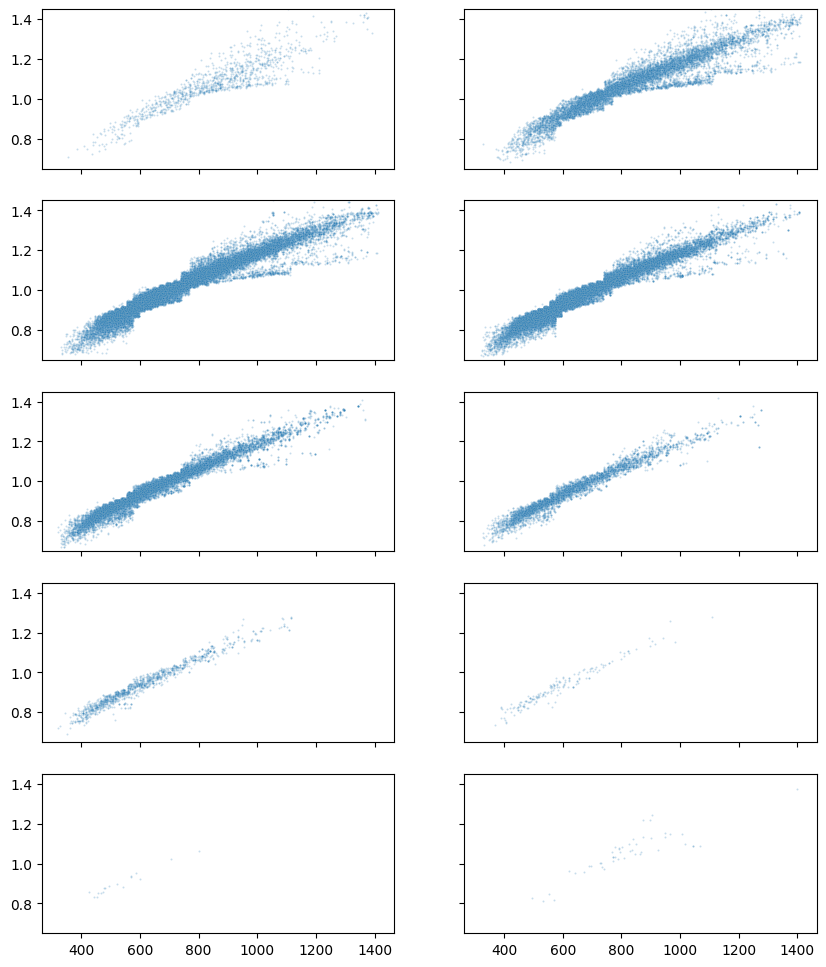

In [ ]:
vals = np.log2(test2[:, sample].layers['Precursor.Quantity'].astype(float).flatten())
mask = vals > 0
edges = np.histogram_bin_edges(vals[mask], bins=10)
sample_ad = test2[:, sample]

fig, ax = plt.subplots(5, 2, figsize=(10, 12), sharex=True, sharey=True)

for i, edge in enumerate(edges):
    temp = sample_ad
    if i == 0:
        mask = np.log2(temp.layers['Precursor.Quantity'].astype(float).flatten()) < edge
        temp = temp[mask]
        print(temp)
        sns.scatterplot(x=np.log2(temp.layers['Precursor.Calibrated.Mz'].astype(float).flatten()),
                y = temp.layers['Exp.1/K0'].astype(float).flatten(), 
                ax = ax[i // 2 - 1, i % 2],
                alpha=0.25, 
                    s=2)
        sns.scatterplot(x=np.log2(temp.layers['Precursor.Calibrated.Mz'].astype(float).flatten()),
                        y = temp.layers['Exp.1/K0'].astype(float).flatten(), 
                ax = ax[i // 2 - 1, i % 2],
                alpha=0.25, 
                    s=2)
        temp = sample_ad
        ax[i // 2 - 1, i % 2].set_ylim(0.65, 1.45)
    elif i == len(edges):
        mask = np.log2(temp.layers['Precursor.Quantity'].astype(float).flatten()) > edge

        temp = temp[mask]
        sns.scatterplot(x=temp.layers['Precursor.Calibrated.Mz'].astype(float).flatten(),
                y = temp.layers['Exp.1/K0'].astype(float).flatten(), 
                alpha=0.25,
                ax=ax[(i + 1) // 2 - 1, (i + 1) % 2], 
                    s=2)
        ax[(i + 1) // 2 - 1, (i + 1) % 2].set_ylim(0.65, 1.45)
        temp = sample_ad
        
    if i < len(edges) - 1:
        log = np.log2(temp.layers['Precursor.Quantity'].astype(float).flatten())
        mask = (log > edge) & (log < edges[i + 1])
        temp = temp[mask]
        sns.scatterplot(x=temp.layers['Precursor.Calibrated.Mz'].astype(float).flatten(),
                    y = temp.layers['Exp.1/K0'].astype(float).flatten(),
                    alpha=0.25, 
                    ax=ax[(i + 1) // 2 - 1,  (i + 1) % 2], 
                    s=2)
        ax[(i + 1) // 2 - 1,  (i + 1) % 2].set_ylim(0.65, 1.45)
fig.show()

<Axes: >

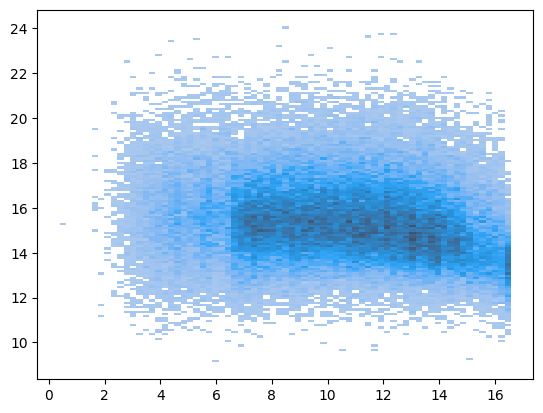

In [137]:
sns.histplot(x=test2[:, sample].layers['RT'].astype(float).flatten(),
             y = np.log2(test2[:, sample].layers['Precursor.Quantity'].astype(float).flatten()))


In [21]:
# Compute average RTDiff for each precursor by input amount
rtdiff_df = test2.to_df('RTDiff')  # Get RTDiff data

# Create a mapping of samples to input amounts
sample_input_map = test2.var['input'].to_dict()

# Group samples by input amount and compute average RTDiff for each precursor
input_groups = {}
rtdiff_avg_results = {}

# Group samples by input amount
for sample, input_amount in sample_input_map.items():
    if input_amount not in input_groups:
        input_groups[input_amount] = []
    input_groups[input_amount].append(sample)

# Compute average RTDiff for each input amount
for input_amount, samples in input_groups.items():
    if pd.isna(input_amount):  # Skip NaN input amounts
        continue
    
    # Get RTDiff data for samples with this input amount
    input_rtdiff = rtdiff_df[samples]
    
    # Remove rows with all zeros or NaN
    input_rtdiff_clean = input_rtdiff[(input_rtdiff != 0).any(axis=1) & input_rtdiff.notna().any(axis=1)]
    
    # Compute mean across samples (axis=1 for rows/precursors) 
    rtdiff_avg = input_rtdiff_clean.mean(axis=1)
    
    # Remove NaN averages
    rtdiff_avg_clean = rtdiff_avg.dropna()
    
    rtdiff_avg_results[input_amount] = rtdiff_avg_clean
    
    print(f"Input amount: {input_amount}")
    print(f"  Number of samples: {len(samples)}")
    print(f"  Number of precursors with valid RTDiff: {len(rtdiff_avg_clean)}")
    print(f"  Mean RTDiff: {rtdiff_avg_clean.mean():.4f} min")
    print(f"  Median RTDiff: {rtdiff_avg_clean.median():.4f} min") 
    print(f"  RTDiff range: {rtdiff_avg_clean.min():.4f} - {rtdiff_avg_clean.max():.4f} min")
    print()

# Create a combined DataFrame for plotting
rtdiff_avg_df_list = []
for input_amount, rtdiff_values in rtdiff_avg_results.items():
    temp_df = pd.DataFrame({
        'Avg_RTDiff': rtdiff_values,
        'input_amount': input_amount,
        'precursor': rtdiff_values.index
    })
    rtdiff_avg_df_list.append(temp_df)

rtdiff_avg_combined = pd.concat(rtdiff_avg_df_list, ignore_index=True)

Input amount: 20ng
  Number of samples: 3
  Number of precursors with valid RTDiff: 101869
  Mean RTDiff: 0.1223 min
  Median RTDiff: 0.1223 min
  RTDiff range: 0.1223 - 0.1225 min

Input amount: 5ng
  Number of samples: 4
  Number of precursors with valid RTDiff: 85132
  Mean RTDiff: 0.1223 min
  Median RTDiff: 0.1223 min
  RTDiff range: 0.1223 - 0.1224 min

Input amount: 50ng
  Number of samples: 3
  Number of precursors with valid RTDiff: 103485
  Mean RTDiff: 0.1223 min
  Median RTDiff: 0.1223 min
  RTDiff range: 0.1223 - 0.1225 min

Input amount: 1ng
  Number of samples: 3
  Number of precursors with valid RTDiff: 46526
  Mean RTDiff: 0.1223 min
  Median RTDiff: 0.1223 min
  RTDiff range: 0.1223 - 0.1225 min

Input amount: 200pg
  Number of samples: 3
  Number of precursors with valid RTDiff: 23845
  Mean RTDiff: 0.1223 min
  Median RTDiff: 0.1223 min
  RTDiff range: 0.1223 - 0.1224 min

Input amount: 100pg
  Number of samples: 3
  Number of precursors with valid RTDiff: 16550
  M

In [ ]:
# Plot average RTDiff distributions by input amount
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Box plot
sns.boxplot(data=rtdiff_avg_combined, x='input_amount', y='Avg_RTDiff', ax=axes[0])
axes[0].set_title('Average RTDiff Distribution by Input Amount')
axes[0].set_ylabel('Average RTDiff (min)')
axes[0].tick_params(axis='x', rotation=45)

# Violin plot for better distribution visualization
sns.violinplot(data=rtdiff_avg_combined, x='input_amount', y='Avg_RTDiff', ax=axes[1]) 
axes[1].set_title('Average RTDiff Distribution by Input Amount (Violin)')
axes[1].set_ylabel('Average RTDiff (min)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Summary statistics table
rtdiff_summary_stats = rtdiff_avg_combined.groupby('input_amount')['Avg_RTDiff'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(4)

print("RTDiff Average Summary Statistics:")
print(rtdiff_summary_stats)

In [103]:
# Get the Precursor.Quantity data
quantity_df = test2.to_df('Precursor.Quantity')

# Create a mapping of samples to input amounts
sample_input_map = test2.var['input'].to_dict()

# Group samples by input amount and compute CV for each precursor
input_groups = {}
cv_results = {}

# Group samples by input amount
for sample, input_amount in sample_input_map.items():
    if input_amount not in input_groups:
        input_groups[input_amount] = []
    input_groups[input_amount].append(sample)

# Compute CV for each input amount
for input_amount, samples in input_groups.items():
    if pd.isna(input_amount):  # Skip NaN input amounts
        continue
    
    # Get data for samples with this input amount
    input_data = quantity_df[samples]
    
    # Remove rows with all zeros or NaN
    input_data_clean = input_data[(input_data > 0).any(axis=1)]
    
    # Compute mean and std across samples (axis=1 for rows/precursors)
    means = input_data_clean.mean(axis=1)
    stds = input_data_clean.std(axis=1)
    
    # Compute CV (std/mean * 100)
    cv = (stds / means) * 100
    
    # Remove infinite or NaN CVs
    cv_clean = cv
    # cv[np.isfinite(cv)]
    
    cv_results[input_amount] = cv_clean
    
    print(f"Input amount: {input_amount}")
    print(f"  Number of samples: {len(samples)}")
    print(f"  Number of precursors with valid CV: {len(cv_clean)}")
    print(f"  Median CV: {cv_clean.median():.2f}%")
    print(f"  Mean CV: {cv_clean.mean():.2f}%")
    print(f"  CV range: {cv_clean.min():.2f}% - {cv_clean.max():.2f}%")
    print()

# Create a combined DataFrame for plotting
cv_df_list = []
for input_amount, cv_values in cv_results.items():
    temp_df = pd.DataFrame({
        'CV': cv_values,
        'input_amount': input_amount
    })
    cv_df_list.append(temp_df)

cv_combined = pd.concat(cv_df_list, ignore_index=True)

Input amount: 20ng
  Number of samples: 3
  Number of precursors with valid CV: 101869
  Median CV: 13.65%
  Mean CV: 18.73%
  CV range: 0.00% - 170.50%

Input amount: 5ng
  Number of samples: 4
  Number of precursors with valid CV: 85132
  Median CV: 16.25%
  Mean CV: 20.32%
  CV range: 0.01% - 192.04%

Input amount: 50ng
  Number of samples: 3
  Number of precursors with valid CV: 103485
  Median CV: 13.80%
  Mean CV: 18.98%
  CV range: 0.00% - 170.92%

Input amount: 1ng
  Number of samples: 3
  Number of precursors with valid CV: 46526
  Median CV: 16.37%
  Mean CV: 20.31%
  CV range: 0.00% - 164.55%

Input amount: 200pg
  Number of samples: 3
  Number of precursors with valid CV: 23845
  Median CV: 20.25%
  Mean CV: 24.00%
  CV range: 0.00% - 167.92%

Input amount: 100pg
  Number of samples: 3
  Number of precursors with valid CV: 16550
  Median CV: 21.64%
  Mean CV: 25.51%
  CV range: 0.00% - 141.93%



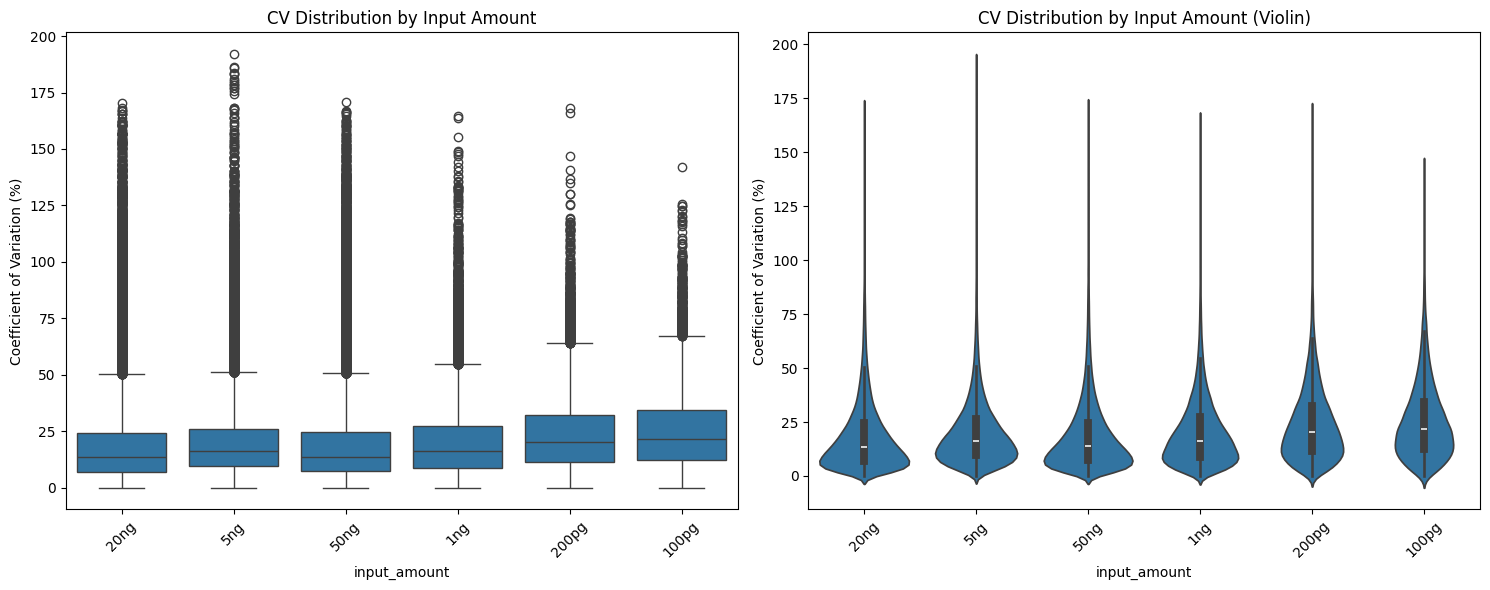

Summary Statistics:
              count       mean     median    std       min         max
input_amount                                                          
100pg         11612  25.509298  21.635233  17.84       0.0  141.932712
1ng           35754  20.313975  16.371298  16.11       0.0  164.554948
200pg         17238  23.998104  20.251623  17.30       0.0  167.919632
20ng          82783  18.730419  13.646994  17.81       0.0  170.502143
50ng          83437   18.98013  13.801746  17.91       0.0  170.915314
5ng           68784  20.316508  16.252553  16.42  0.008961  192.035957


In [104]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Box plot
sns.boxplot(data=cv_combined, x='input_amount', y='CV', ax=axes[0])
axes[0].set_title('CV Distribution by Input Amount')
axes[0].set_ylabel('Coefficient of Variation (%)')
axes[0].tick_params(axis='x', rotation=45)

# Violin plot for better distribution visualization
sns.violinplot(data=cv_combined, x='input_amount', y='CV', ax=axes[1])
axes[1].set_title('CV Distribution by Input Amount (Violin)')
axes[1].set_ylabel('Coefficient of Variation (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Summary statistics table
summary_stats = cv_combined.groupby('input_amount')['CV'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)

print("Summary Statistics:")
print(summary_stats)

KeyboardInterrupt: 

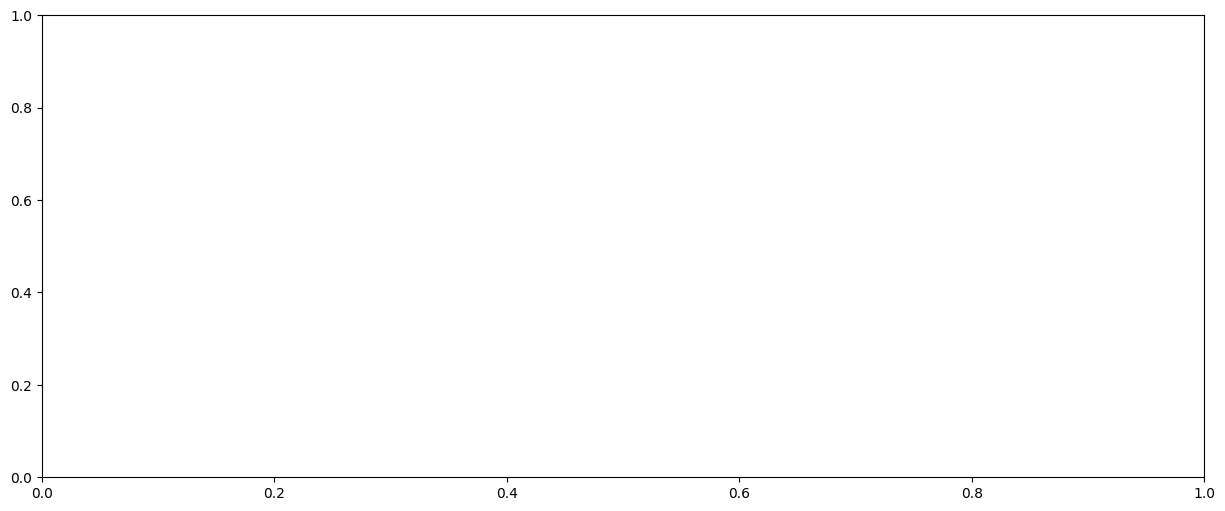

In [30]:
# check_dist(bpscollection.data['precursor'], 'Q.Value', figsize=(15,6))

#### Filtering 

* *are RT being shifted in the flow drop or are we losing peptides?
* how are they being shifted? earlier or later?

#### Plotting RT Diff

<Axes: xlabel='HeLa_50ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_19mv45_DIA50msW122_TT0000391_B-A6_1_14795', ylabel='Count'>

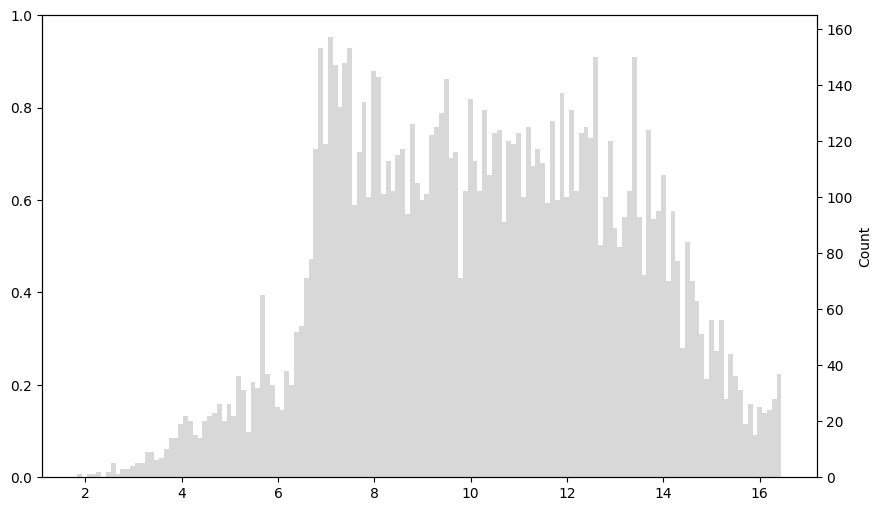

In [111]:
fig, ax = plt.subplots(figsize=(10,6))
ax2 = ax.twinx()

test4 = bpscollection.data['precursor'].to_df('RT')

sns.histplot(test4['HeLa_50ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_19mv45_DIA50msW122_TT0000391_B-A6_1_14795'], 
             ax=ax2, 
             alpha=0.3, 
             edgecolor=None, 
             color='grey', binwidth=0.1)

<Axes: xlabel='HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p5m150nlv5_DIA75msW83_TT0000216_B-B1_1_14617', ylabel='Count'>

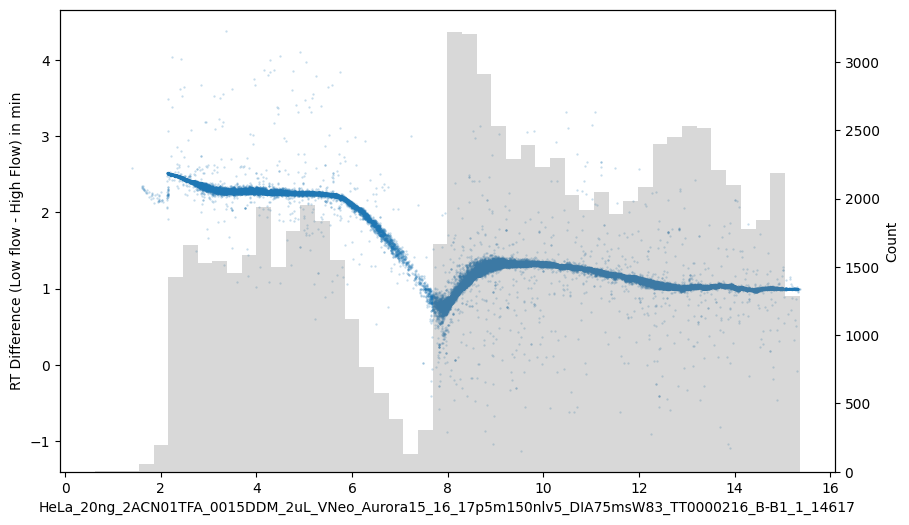

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
ax2 = ax.twinx()

test4 = bpscollection.data['precursor'].to_df('RT')
sns.scatterplot(x = test4['HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p5m150nlv5_DIA75msW83_TT0000216_B-B1_1_14617'],
                y= test4['HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_20p5m150nlv5_DIA75msW83_TT0000215_B-B1_1_14616'] - test4['HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p5m150nlv5_DIA75msW83_TT0000216_B-B1_1_14617'] - 2,
                y= test4['HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_20p5m150nlv5_DIA75msW83_TT0000215_B-B1_1_14616'] - test4['HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p5m150nlv5_DIA75msW83_TT0000216_B-B1_1_14617'] - 2,
                s=2,
                alpha=0.25,
                edgecolor=None,
                ax=ax)
ax.set_ylabel('RT Difference (Low flow - High Flow) in min')
sns.histplot(test4['HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p5m150nlv5_DIA75msW83_TT0000216_B-B1_1_14617'] , ax=ax2, alpha=0.3, edgecolor=None, color='grey')

<Axes: >

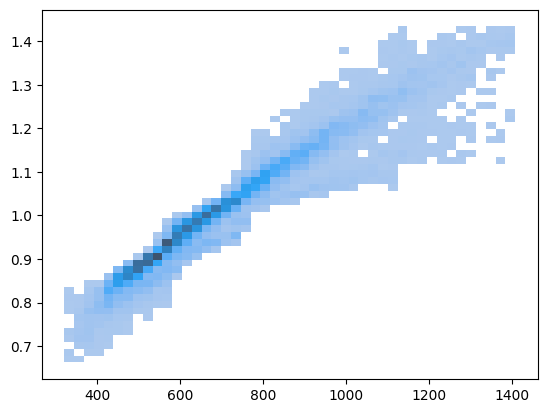

In [47]:
sns.histplot(x=test3.layers['Precursor.Calibrated.Mz'].flatten(), 
             y= test3.layers['Exp.1/K0'].flatten())

<Axes: ylabel='Count'>

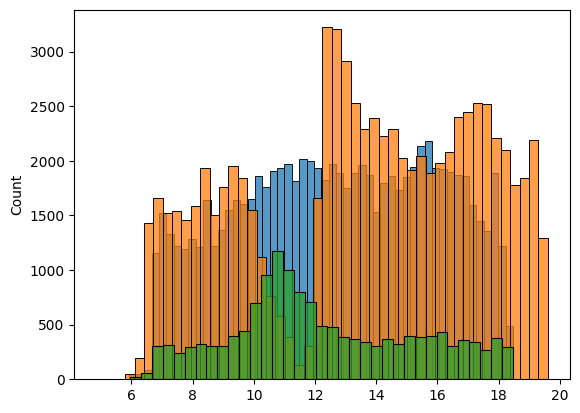

In [64]:
sns.histplot(test2[:, test2.var['hystar_index'].isin(['14616'])].layers['RT'].flatten())
sns.histplot(test2[:, test2.var['hystar_index'].isin(['14617'])].layers['RT'].flatten() + 4.25)

sns.histplot(test3.layers['RT'].flatten()) 

/hpc/mydata/eileen.wang/anaconda/25.3.1/x86_64/envs/methodanalysis/lib/python3.11/site-packages/anndata/_core/anndata.py:1813: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


<Axes: ylabel='Count'>

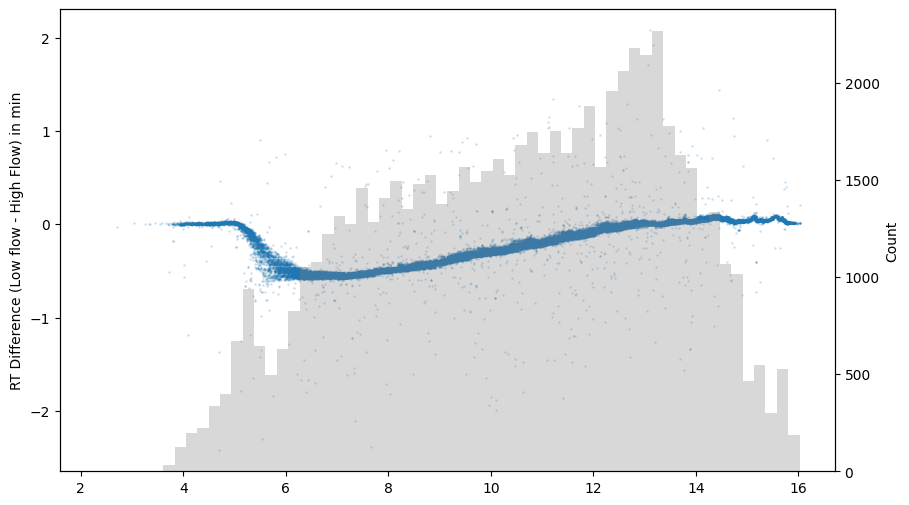

In [172]:
fig, ax = plt.subplots(figsize=(10,6))
ax2 = ax.twinx()

test = bpscollection.data['precursor'].copy()
sns.scatterplot(x = test[:, test.var['hystar_index'].isin(['14648'])].layers['RT'].flatten(),
                y= test[:, test.var['hystar_index'].isin(['14648'])].layers['RT'].flatten() - test[:, test.var['hystar_index'].isin(['14642'])].layers['RT'].flatten(),
                s=2,
                alpha=0.25,
                edgecolor=None,
                ax=ax)
ax.set_ylabel('RT Difference (Low flow - High Flow) in min')
sns.histplot(test[:, test.var['hystar_index'].isin(['14648'])].layers['RT'].flatten(), ax=ax2, alpha=0.3, edgecolor=None, color='grey')

#### Elution Param + Dist Mapping

In [126]:
df = elution_param(lccollection, bpscollection, 'HeLa_5ng_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_18p6m200nlv30_DIA75msW83_TT0000247_B-A1_1_14648')

Total volume passed at rt_min (2.28 min): 1142.81 nL
1142.8073404285715


/hpc/mydata/eileen.wang/anaconda/25.3.1/x86_64/envs/methodanalysis/lib/python3.11/site-packages/anndata/_core/anndata.py:1813: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


<Axes: title={'center': 'Gradient Comparison: 18p6m200nlv30'}, xlabel='time [min]', ylabel='Value [%]'>

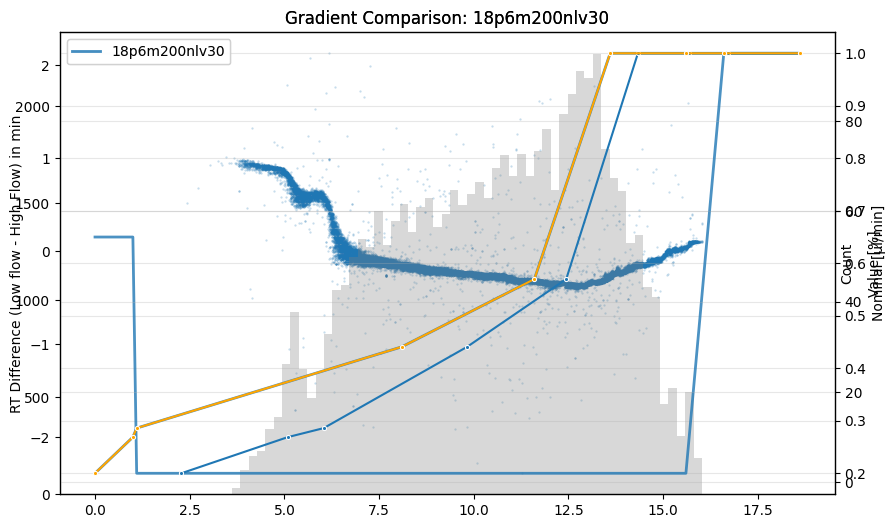

In [197]:
fig, ax = plt.subplots(figsize=(10,6))
ax2 = ax.twinx()
ax3 = ax.twinx()
ax4 = ax2.twinx()
sns.scatterplot(x = test[:, test.var['hystar_index'].isin(['14648'])].layers['RT'].flatten(),
                y= test[:, test.var['hystar_index'].isin(['14648'])].layers['RT'].flatten() - test[:, test.var['hystar_index'].isin(['14649'])].layers['RT'].flatten(),
                s=2,
                alpha=0.25,
                edgecolor=None,
                ax=ax)
ax.set_ylabel('RT Difference (Low flow - High Flow) in min')
sns.histplot(test[:, test.var['hystar_index'].isin(['14648'])].layers['RT'].flatten(), ax=ax2, alpha=0.3, edgecolor=None, color='grey')
# sns.histplot(test[:, test.var['hystar_index'].isin(['14649'])].layers['RT'].flatten(), ax=ax2, alpha=0.3, edgecolor=None, color='blue')


lccollection.plot_gradients(['18p6m200nlv30'], y_cols = ['Neo.PumpModule.Pump.Flow.Nominal [µl/min]'], ax = ax3)
lccollection.plot_gradients(['18p6m200nlv30'], y_cols = ['Neo.PumpModule.Pump.%B.Value [%]'], ax = ax4)

sns.lineplot(data = df, x = 'Actual Time to Elute Nominal %B (min)', y='Neo.PumpModule.Pump.%B.Value [%]', ax=ax4, marker='.')
sns.lineplot(data = df, x = 'time [min]', y='Neo.PumpModule.Pump.%B.Value [%]', ax=ax4, color='orange', marker='.')

#### Filtering/Counting Workshop

In [17]:
sc.pp.filter_cells(test, min_genes=0) # number of samples in which a given feature is quantified, based on X
sc.pp.filter_genes(test, min_cells=0) # number of features quantified in a given sample, based on X

In [ ]:
filter_mask(test, 
            filter_name = 'mask', 
            strict=False, 
            layer_threshold={'Q.Value': (0.01, 'max'),
                             'Lib.Q.Value': (0.01, 'max'), 
                             'Precursor.Quantity': (0, 'min')})

#### Gradients

<Axes: title={'center': 'Gradient Comparison: 25m200nlv24, 18p6m200nlv28drop'}, xlabel='time [min]', ylabel='Nominal [µl/min]'>

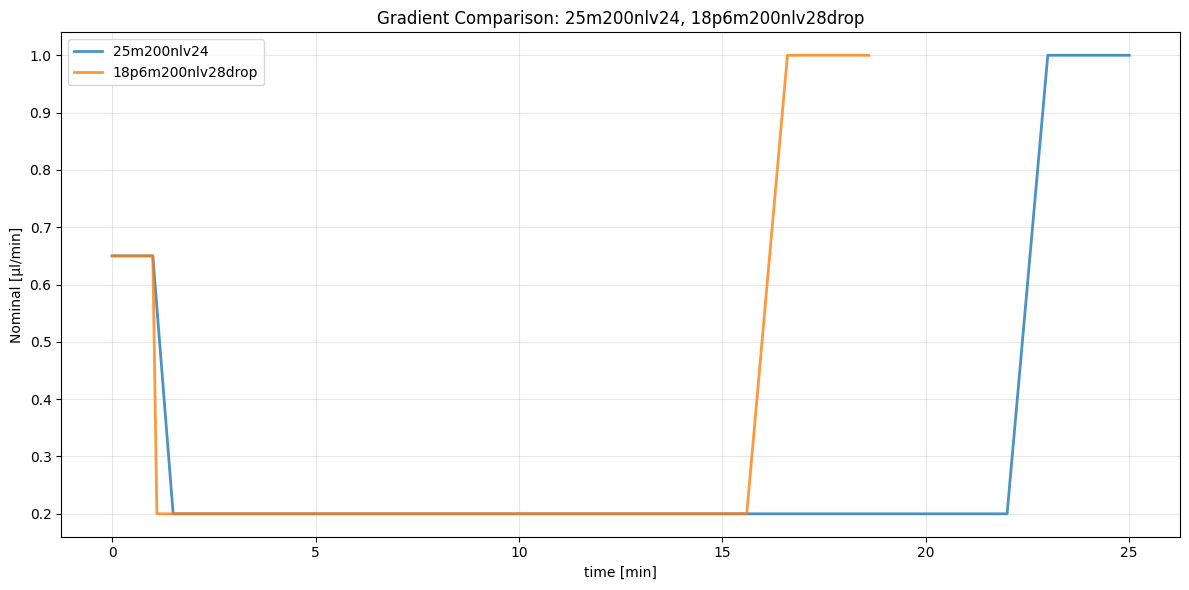

In [ ]:
lccollection.plot_gradients(['25m200nlv24', '18p6m200nlv28drop'], y_cols = ['Neo.PumpModule.Pump.Flow.Nominal [µl/min]'])

#### Ion Mobility Errir

(-0.2, 0.2)

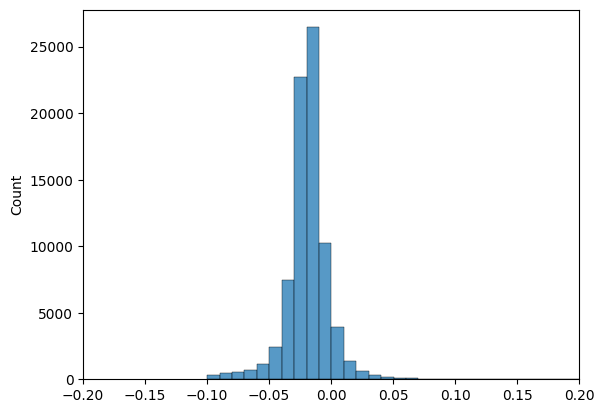

In [66]:
sns.histplot((sample.layers['Lib.1/K0'] - sample.layers['Exp.1/K0']).flatten(), binwidth =0.01)
plt.xlim(-0.2, 0.2)

#### Precursors vs MZ

## Plotter OBject

In [231]:
pl = Plotter()

#### MZ/IM

/hpc/mydata/eileen.wang/anaconda/25.3.1/x86_64/envs/methodanalysis/lib/python3.11/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 's'
  cset = contour_func(


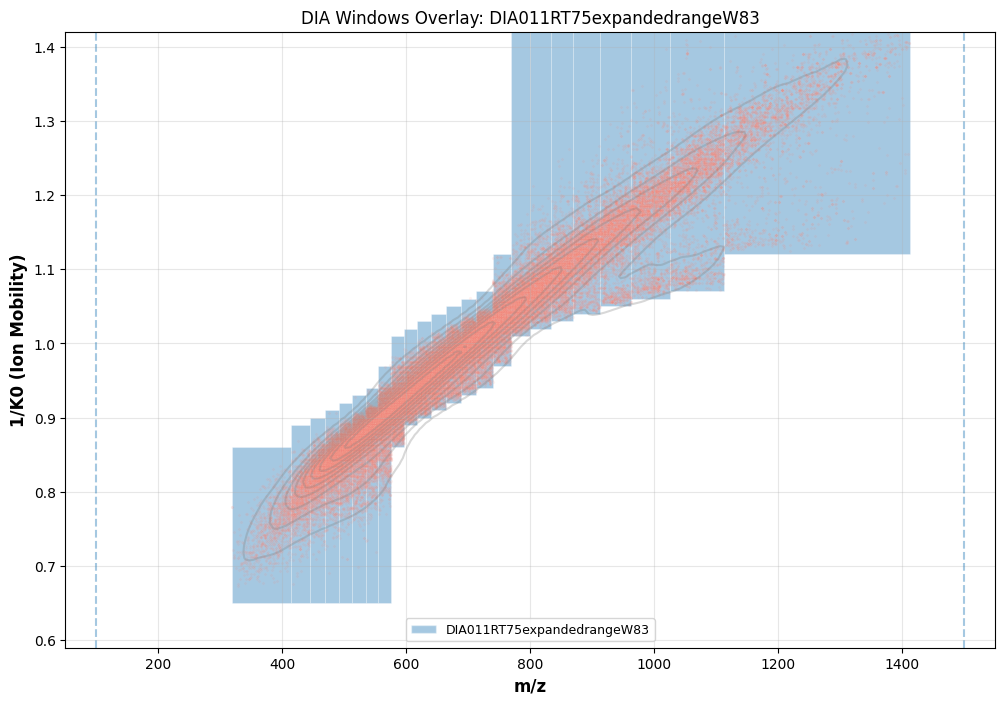

In [232]:
pl.plot_precursor_mz_im(bpscollection.data['precursor'],
                        'HeLa_5ng_2ACN01TFA_0015DDM_1uL_VNeo_Aurora15_16_18p6m200nlv30_DIA75msW83_TT0000247_B-A1_1_14648', 
                        mscollection, 
                        hue=None)

/hpc/mydata/eileen.wang/anaconda/25.3.1/x86_64/envs/methodanalysis/lib/python3.11/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 's'
  cset = contour_func(


TypeError: unhashable type: 'Series'

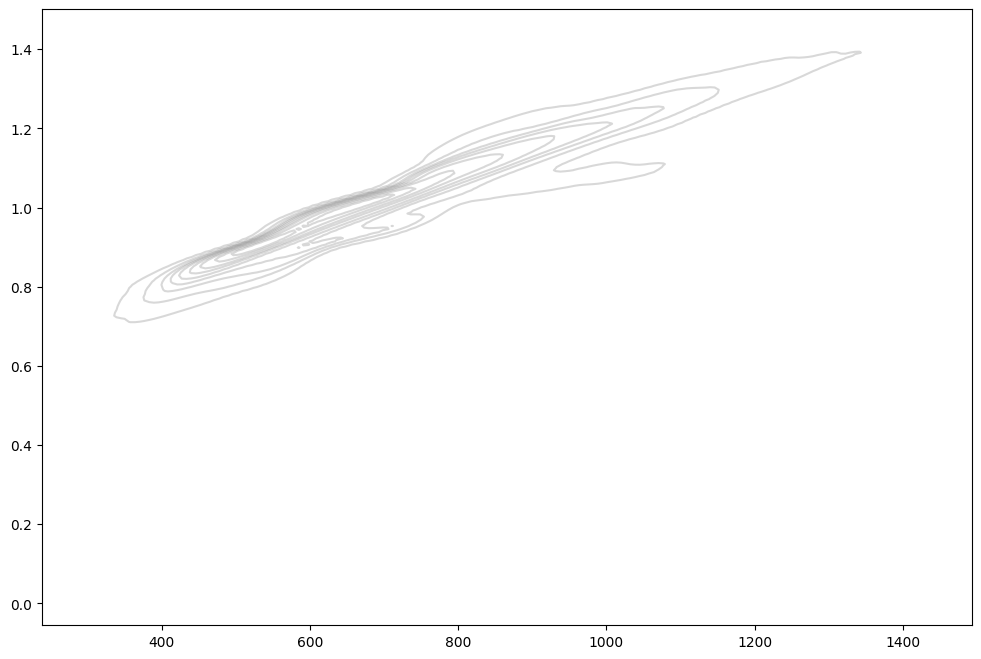

In [236]:
pl.plot_precursor_mz_im(bpscollection.data['precursor'],
                        'HeLa_50ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_23p65m150nlv18Zebra_DIA75msW83_TT0000230_B-A1_1_14631', 
                        mscollection, 
                        hue=None)

### Plotting Differences
* Analyzing bias introduced by the LC gradient

#### IM vs RT

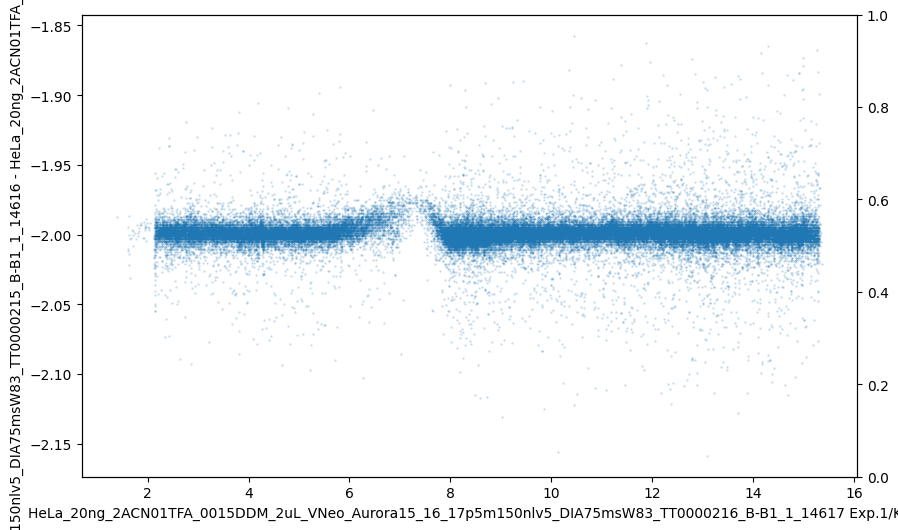

In [219]:
fig, ax = plt.subplots(figsize=(10,6))
ax2 = ax.twinx()

pl.scatterplot_difference(bpscollection.data['precursor'],
                          'HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p5m150nlv5_DIA75msW83_TT0000216_B-B1_1_14617',
                          'HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_20p5m150nlv5_DIA75msW83_TT0000215_B-B1_1_14616',
                          layer = 'Exp.1/K0',
                          x='RT',
                          ax = ax,
                          y_shift=2)

# sns.histplot(test4['HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p5m150nlv5_DIA75msW83_TT0000216_B-B1_1_14617'] , ax=ax2, alpha=0.3, edgecolor=None, color='grey')

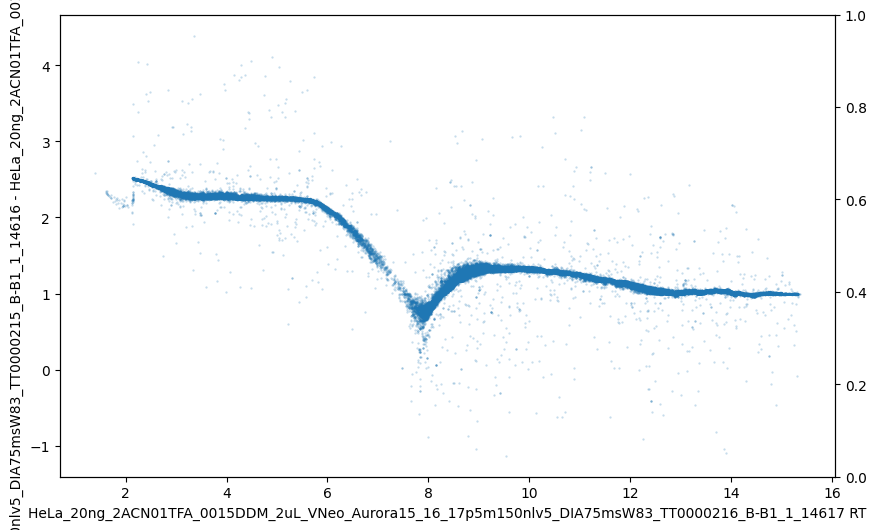

In [221]:
fig, ax = plt.subplots(figsize=(10,6))
ax2 = ax.twinx()

pl.scatterplot_difference(bpscollection.data['precursor'],
                          'HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p5m150nlv5_DIA75msW83_TT0000216_B-B1_1_14617',
                          'HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_20p5m150nlv5_DIA75msW83_TT0000215_B-B1_1_14616',
                          layer = 'RT',
                          ax = ax,
                          y_shift=2)

#### Calculating Coverage

In [ ]:
sample_adata = bpscollection.data['precursor'][:, 'sample_name']
dia_windows = mscollection['method_name'].get_dia_windows()

coverage_df = analyze_sample_coverage(sample_adata, dia_windows)
summary = summarize_coverage(coverage_df)

print(f"Coverage: {summary['coverage_rate']:.1f}%")
print(f"Covered: {summary['covered_precursors']} / {summary['total_precursors']}")

summary

# Analyzing Methods

1. How many precursors are being collected/detected per cycle?
2. How many precusors are being collected per unit time?
3. What percentage of precursors do our DIA windows collect?
   * Which precursors does it leave out?
   * Evaluating window size vs precursors actually in a window per unit time? 
4. What is the difference in number of precursors detected per sample/run?
   * How do they plot in terms of RT, IM, MZ, etc
5. Carryover?
   * % of total intensity 
   * % vs intensity in previous sample
   * properties of carrover/distribution vs RT